# Mini Proyecto Final – Data Analytics

## Alumno: Lucas Pistoleso

## Coderhouse

In [1]:
!pip install pandas numpy matplotlib scipy openpyxl

# 1. Importación de librerías

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import re

# 2. Carga de los datasets

In [3]:
from google.colab import files
uploaded = files.upload()

tablas = pd.read_excel('ventas_adidas_dataset.xlsx', sheet_name=None)
print(tablas.keys())

ventas = tablas['VENTAS']
minoristas = tablas['MINORISTAS']
ciudades = tablas['CIUDADES']
estados = tablas['ESTADOS']
regiones = tablas['REGIONES']
metodos_venta = tablas['METODOS VENTA']
categorias_producto = tablas['CATEGORIAS PRODUCTO']

ventas.head()

Saving ventas_adidas_dataset.xlsx to ventas_adidas_dataset (1).xlsx
dict_keys(['VENTAS', 'MINORISTAS', 'CIUDADES', 'ESTADOS', 'REGIONES', 'METODOS VENTA', 'CATEGORIAS PRODUCTO'])


,Venta_ID,Fecha_facturacion,Minorista_ID,Ciudad_ID,Cat_Producto_ID,Precio_unitario,Unidades_vendidas,Total_ventas,Ganancia,Margen,Metodo_venta_ID
0,6728,2021-07-12,91,40,5,56.0,91,5096,2344.16,0.46,3
1,9079,16/03/2021,83,37,4,15.0,85,1275,573.75,0.45,2
2,4791,08/02/2021,26,13,1,42.0,203,8526,4945.08,0.58,3
3,7346,2021/02/08,109,49,5,41.0,47,1927,770.80,0.40,3
4,8116,2021-10-05,13,6,2,29.0,219,6351,2984.97,0.47,2


# 3. Exploración inicial de los datos

In [4]:
print("Forma del DataFrame:", ventas.shape)

print("\n--- Tipos de dato ---")
print(ventas.dtypes)

print("\n--- Valores nulos por columna ---")
print(ventas.isnull().sum())

print("\n--- Filas duplicadas exactas ---")
print(ventas.duplicated().sum())

print("\n--- ¿Qué tipos de datos conviven en Total_ventas? ---")
print(ventas['Total_ventas'].apply(type).value_counts())

Forma del DataFrame: (9665, 11)

--- Tipos de dato ---
Venta_ID               int64
Fecha_facturacion     object
Minorista_ID           int64
Ciudad_ID              int64
Cat_Producto_ID        int64
Precio_unitario      float64
Unidades_vendidas      int64
Total_ventas          object
Ganancia             float64
Margen               float64
Metodo_venta_ID        int64
dtype: object

--- Valores nulos por columna ---
Venta_ID               0
Fecha_facturacion      0
Minorista_ID           0
Ciudad_ID              0
Cat_Producto_ID        0
Precio_unitario      193
Unidades_vendidas      0
Total_ventas           0
Ganancia               0
Margen                 0
Metodo_venta_ID        0
dtype: int64

--- Filas duplicadas exactas ---
20

--- ¿Qué tipos de datos conviven en Total_ventas? ---
Total_ventas
<class 'int'>      8683
<class 'float'>     886
<class 'str'>        96
Name: count, dtype: int64


# 4. Limpieza y preparación de datos

In [5]:
ventas['Total_ventas'] = pd.to_numeric(ventas['Total_ventas'], errors='coerce')
print(ventas['Total_ventas'].dtype)
print(ventas['Total_ventas'].isnull().sum())

float64
96


In [6]:
def parsear_fecha(valor):
    valor = str(valor).strip()
    if re.match(r'^\d{4}-\d{2}-\d{2}$', valor):
        return pd.to_datetime(valor, format='%Y-%m-%d')
    elif re.match(r'^\d{4}/\d{2}/\d{2}$', valor):
        return pd.to_datetime(valor, format='%Y/%m/%d')
    elif re.match(r'^\d{2}/\d{2}/\d{4}$', valor):
        return pd.to_datetime(valor, format='%d/%m/%Y')
    elif re.match(r'^\d{2}-\d{2}-\d{4}$', valor):
        return pd.to_datetime(valor, format='%d-%m-%Y')
    else:
        return pd.NaT

ventas['Fecha_facturacion'] = ventas['Fecha_facturacion'].apply(parsear_fecha)
print(ventas['Fecha_facturacion'].dtype)
print(ventas['Fecha_facturacion'].isnull().sum())

datetime64[ns]
0


In [7]:
mediana_precio = ventas['Precio_unitario'].median()
ventas['Precio_unitario'] = ventas['Precio_unitario'].fillna(mediana_precio)

In [8]:
filas_antes = len(ventas)
ventas = ventas.dropna(subset=['Total_ventas'])
print(f"Filas eliminadas por Total_ventas nulo: {filas_antes - len(ventas)}")
print(ventas.isnull().sum())

Filas eliminadas por Total_ventas nulo: 96
Venta_ID             0
Fecha_facturacion    0
Minorista_ID         0
Ciudad_ID            0
Cat_Producto_ID      0
Precio_unitario      0
Unidades_vendidas    0
Total_ventas         0
Ganancia             0
Margen               0
Metodo_venta_ID      0
dtype: int64


In [9]:
filas_antes = len(ventas)
ventas = ventas.drop_duplicates()
print(f"Duplicados eliminados: {filas_antes - len(ventas)}")
print("Forma final:", ventas.shape)

Duplicados eliminados: 20
Forma final: (9549, 11)


# 5. Integración de tablas

In [10]:
print("Filas antes de mergear:", len(ventas))

minoristas_dedup = minoristas.drop_duplicates(subset='Minorista_ID')
categorias_dedup = categorias_producto.drop_duplicates(subset='Cat_Producto_ID')

ventas_completo = ventas.merge(metodos_venta, on='Metodo_venta_ID', how='left')
ventas_completo = ventas_completo.merge(categorias_dedup, on='Cat_Producto_ID', how='left')
ventas_completo = ventas_completo.merge(ciudades, on='Ciudad_ID', how='left')
ventas_completo = ventas_completo.merge(estados, on='Estado_ID', how='left')
ventas_completo = ventas_completo.merge(regiones, on='Region_ID', how='left')
ventas_completo = ventas_completo.merge(minoristas_dedup[['Minorista_ID', 'Minorista']], on='Minorista_ID', how='left')

print("Filas después de mergear:", len(ventas_completo))
ventas_completo.head()

Filas antes de mergear: 9549
Filas después de mergear: 9549


,Venta_ID,Fecha_facturacion,Minorista_ID,Ciudad_ID,Cat_Producto_ID,Precio_unitario,Unidades_vendidas,Total_ventas,Ganancia,Margen,Metodo_venta_ID,Metodo_venta,Cat_Producto,Ciudad,Estado_ID,Region_ID,Estado,Region,Minorista
0,6728,2021-07-12,91,40,5,56.0,91,5096.0,2344.16,0.46,3,Online,Men's Apparel,"Wichita, Estados Unidos",16,4,Kansas,Midwest,Kohl's
1,9079,2021-03-16,83,37,4,15.0,85,1275.0,573.75,0.45,2,Outlet,Women's Athletic Footwear,"Jackson, Estados Unidos",24,2,Mississippi,South,Foot Locker
2,4791,2021-02-08,26,13,1,42.0,203,8526.0,4945.08,0.58,3,Online,Men's Street Footwear,"Billings, Estados Unidos",26,4,Montana,Midwest,Kohl's
3,7346,2021-02-08,109,49,5,41.0,47,1927.0,770.80,0.40,3,Online,Men's Apparel,"Newark, Estados Unidos",30,1,New Jersey,Northeast,Kohl's
4,8116,2021-10-05,13,6,2,29.0,219,6351.0,2984.97,0.47,2,Outlet,Men's Athletic Footwear,"Dallas, Estados Unidos",43,2,Texas,South,Sports Direct


# 6. Medidas de tendencia central

In [11]:
numericas = ['Total_ventas', 'Precio_unitario', 'Unidades_vendidas', 'Ganancia', 'Margen']

for col in numericas:
    media = ventas_completo[col].mean()
    mediana = ventas_completo[col].median()
    moda = ventas_completo[col].mode()[0]
    print(f"--- {col} ---")
    print(f"Media: {media:.2f} | Mediana: {mediana:.2f} | Moda: {moda:.2f}\n")

--- Total_ventas ---
Media: 93200.50 | Mediana: 9581.00 | Moda: 100000.00

--- Precio_unitario ---
Media: 45.35 | Mediana: 45.00 | Moda: 45.00

--- Unidades_vendidas ---
Media: 256.89 | Mediana: 176.00 | Moda: 225.00

--- Ganancia ---
Media: 34396.18 | Mediana: 4365.36 | Moda: 105000.00

--- Margen ---
Media: 0.42 | Mediana: 0.41 | Moda: 0.35



In [12]:
categoricas = ['Metodo_venta', 'Region', 'Cat_Producto', 'Minorista']

for col in categoricas:
    moda = ventas_completo[col].mode()[0]
    frecuencia = ventas_completo[col].value_counts().iloc[0]
    print(f"{col} -> Moda: {moda} (aparece {frecuencia} veces)")

Metodo_venta -> Moda: Online (aparece 4843 veces)
Region -> Moda: West (aparece 2420 veces)
Cat_Producto -> Moda: Women's Apparel (aparece 1597 veces)
Minorista -> Moda: Foot Locker (aparece 2608 veces)


En Total_ventas y Ganancia, la media es mucho mayor que la mediana: hay un grupo chico de ventas muy grandes que estira el promedio, mientras que la venta "típica" es bastante más chica. En estos casos la mediana representa mejor el día a día del negocio. La moda en variables continuas (Margen, Precio_unitario) es poco informativa porque casi no se repiten valores exactos. En las categóricas sí aporta: Online es el método de venta más frecuente, West la región con más operaciones, y Foot Locker el minorista más recurrente.

# 7. Segmentación por región

In [13]:
def moda_segura(serie):
    moda = serie.mode()
    return moda.iloc[0] if not moda.empty else np.nan

# Segmentación por Región
resumen_region = ventas_completo.groupby('Region')['Total_ventas'].agg(
    Media='mean', Mediana='median', Moda=moda_segura, Cantidad_ventas='count'
).round(2).sort_values('Media', ascending=False)
print(resumen_region)

print()

# Segmentación por Método de venta
resumen_metodo = ventas_completo.groupby('Metodo_venta')['Total_ventas'].agg(
    Media='mean', Mediana='median', Moda=moda_segura, Cantidad_ventas='count'
).round(2).sort_values('Media', ascending=False)
print(resumen_metodo)

print()

# Margen promedio por región
margen_region = ventas_completo.groupby('Region')['Margen'].mean().round(3).sort_values(ascending=False)
print(margen_region)

               Media  Mediana      Moda  Cantidad_ventas
Region                                                  
Southeast  133611.61  12642.0  192500.0             1219
West       109900.23  10080.0  180000.0             2420
South       84203.03   8136.5  150000.0             1712
Northeast   77576.47   7777.5  100000.0             2348
Midwest     72883.96  12684.5   90000.0             1850

                  Media   Mediana      Moda  Cantidad_ventas
Metodo_venta                                                
In-store      205056.91  168750.0  100000.0             1722
Outlet         97470.64    8856.0  123750.0             2984
Online         50797.28    6232.0  112500.0             4843

Region
South        0.467
Midwest      0.435
Southeast    0.419
Northeast    0.411
West         0.396
Name: Margen, dtype: float64


# 8. Visualizaciones

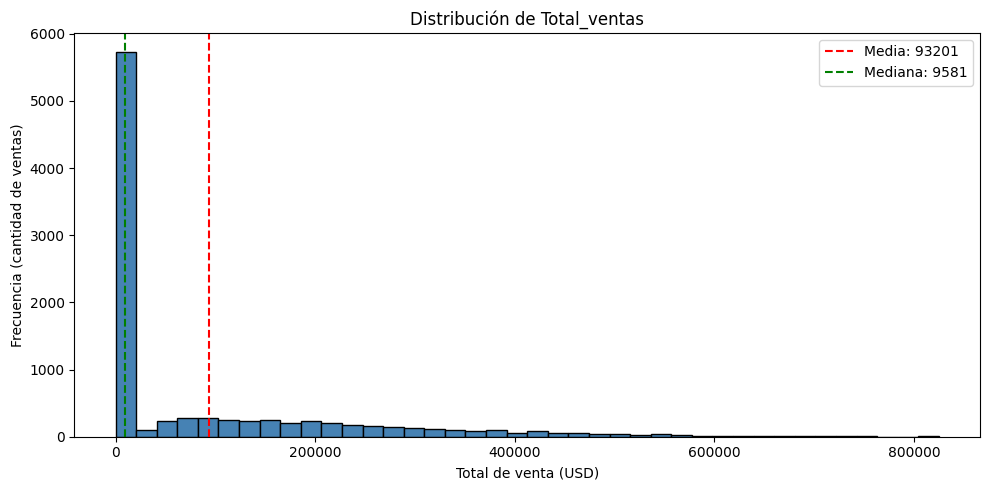

In [14]:
# Histograma de Total_ventas
plt.figure(figsize=(10, 5))
plt.hist(ventas_completo['Total_ventas'], bins=40, color='steelblue', edgecolor='black')
plt.title('Distribución de Total_ventas')
plt.xlabel('Total de venta (USD)')
plt.ylabel('Frecuencia (cantidad de ventas)')
plt.axvline(ventas_completo['Total_ventas'].mean(), color='red', linestyle='--',
            label=f"Media: {ventas_completo['Total_ventas'].mean():.0f}")
plt.axvline(ventas_completo['Total_ventas'].median(), color='green', linestyle='--',
            label=f"Mediana: {ventas_completo['Total_ventas'].median():.0f}")
plt.legend()
plt.tight_layout()
plt.show()

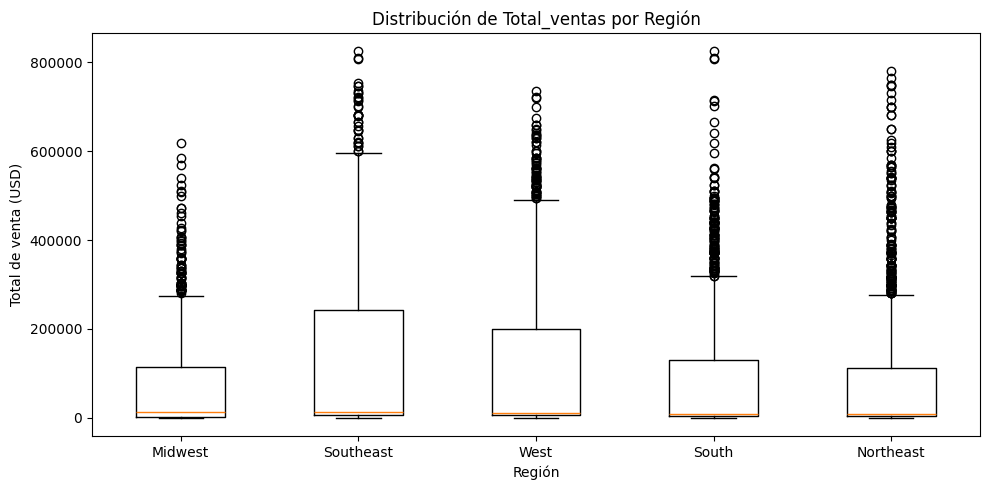

In [15]:
# Boxplot de Total_ventas por Región
plt.figure(figsize=(10, 5))
orden = ventas_completo.groupby('Region')['Total_ventas'].median().sort_values(ascending=False).index
datos = [ventas_completo[ventas_completo['Region'] == r]['Total_ventas'] for r in orden]
plt.boxplot(datos, tick_labels=orden)
plt.title('Distribución de Total_ventas por Región')
plt.xlabel('Región')
plt.ylabel('Total de venta (USD)')
plt.tight_layout()
plt.show()

# 9. Conclusiones

1.   La región South tiene el mejor margen (0,467) pese a no liderar en volumen ni en venta promedio. Esto sugiere que algo en su mix de productos, canal o pricing es más eficiente que en el resto. Acción: analizar qué combinación de categoría/método de venta predomina en South y evaluar si se puede replicar en otras regiones para mejorar la rentabilidad general, no solo el volumen.
2.  West concentra la mayor cantidad de operaciones (2.420) pero tiene el margen más bajo (0,396) de las cinco regiones. Mucho volumen no se está traduciendo en mejor rentabilidad relativa. Acción: revisar la política de precios/descuentos en West — podría estar compensando volumen con márgenes más ajustados de forma poco sostenible.
3.  Online es por lejos el canal con más operaciones (4.843) pero el de menor venta promedio (50.797), mientras que In-store tiene pocas operaciones (1.722) pero el ticket más alto (205.057). Acción: para el canal Online, priorizar estrategias de cross-selling o bundles que eleven el ticket promedio, ya que el volumen de tráfico/operaciones ya está asegurado — el margen de mejora está en el valor por venta, no en la cantidad de ventas.